# Importar librerías

In [2]:
# Librerías para cargar y manipular datos
import pandas as pd
import numpy as np
from pathlib import Path

# Librerías para visualización
from matplotlib import pyplot as plt
import seaborn as sns

# Cargar recursos

In [3]:
# Directorio donde se encuentran los resultados de las ejecuciones de la fase 1 del experimento
# de autoencoder global
OUTPUT_FOLDER = Path("../../outputs/runs/nbaiot_autoencoder_global_stage_1/configs")

# Identificador de las configuraciones de los modelos a analizar
MODEL_IDS = [
    "model_1_base_mse",
    "model_2_base_mae",
    "model_3_higher_capacity_mse",
    "model_4_base_regularized_mse",
    "model_5_higher_capacity_regularized_mse",
]

In [4]:
# Cargar en un mismo dataframe los historiales de entrenamiento de los modelos entrenados para cada dispositivo
histories = []
for model_id in MODEL_IDS:
    history_path = OUTPUT_FOLDER / model_id / "history.csv"

    history_df = pd.read_csv(history_path)

    history_df["model_id"] = model_id

    histories.append(history_df)

histories_df = pd.concat(histories, ignore_index=True)

histories_df = histories_df[
    ["model_id", "epoch", "loss", "val_loss"]
]

# Analizar procesos de entrenamiento

En este *notebook* se analiza el comportamiento de las distintas configuraciones propuestas para el autoencoder global durante el proceso de entrenamiento. Al igual que en la estrategia de autoencoder específico por dispositivo, el objetivo de este primer *stage* no es seleccionar todavía el modelo definitivo, sino estudiar cómo afectan las diferentes decisiones de diseño al aprendizaje del tráfico benigno.

Este análisis permitirá identificar las arquitecturas más prometedoras y descartar aquellas configuraciones que presenten un comportamiento claramente inferior antes de proceder a la optimización de hiperparámetros en el siguiente *stage*.

In [7]:
def plot_training_metric_comparison(
    aggregated_df: pd.DataFrame,
    model_labels: dict[str, str],
    metric_col: str,
    ylabel: str,
    title: str,
) -> None:
    plt.figure(figsize=(10, 6))

    for model_id, model_label in model_labels.items():
        model_df = aggregated_df[
            aggregated_df["model_id"] == model_id
        ].sort_values("epoch")

        plt.plot(
            model_df["epoch"],
            model_df[metric_col],
            linewidth=2,
            label=model_label,
        )

    plt.xlabel("Época")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1. Influencia de la función de pérdida

La primera comparación se centra en estudiar el efecto de la función de pérdida sobre el entrenamiento del autoencoder global. Para ello se comparan 2 configuraciones con la misma arquitectura, manteniendo constantes el resto de hiperparámetros y modificando únicamente la función objetivo utilizada durante el aprendizaje.

Esta comparación permite comprobar si, en el caso del modelo global, el uso de MAE aporta una mayor estabilidad o una mejor capacidad de reconstrucción que MSE, o si por el contrario MSE sigue siendo una opción suficientemente robusta para modelar el tráfico benigno agregado de todos los dispositivos.

In [11]:
LOSS_COMPARISON_MODELS = {
    "model_1_base_mse": "Modelo 1 — Base + MSE",
    "model_2_base_mae": "Modelo 2 — Base + MAE",
}

loss_comparison_df = histories_df[
    histories_df["model_id"].isin(LOSS_COMPARISON_MODELS.keys())
].copy()

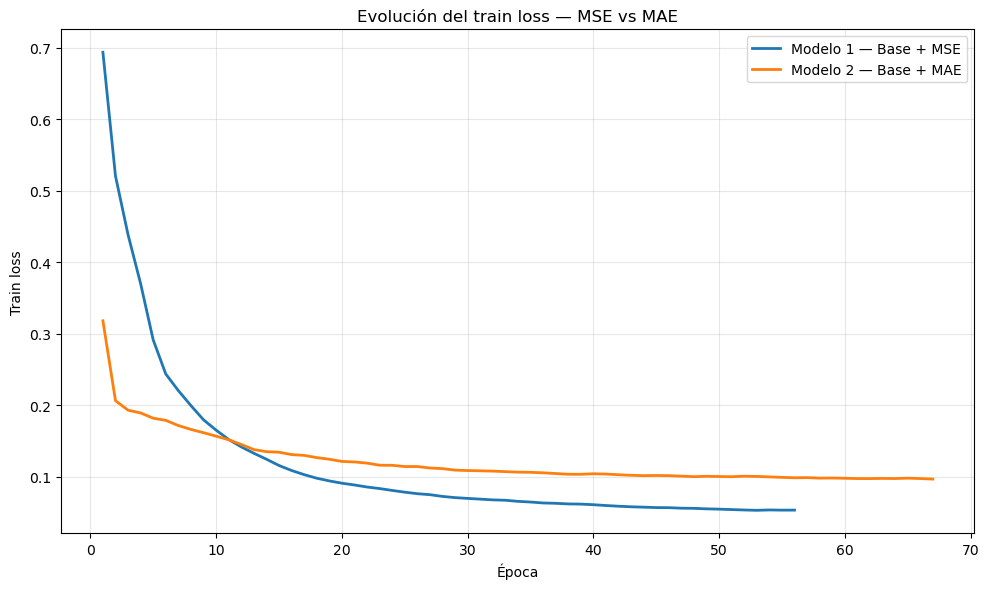

In [12]:
plot_training_metric_comparison(
    aggregated_df=loss_comparison_df,
    model_labels=LOSS_COMPARISON_MODELS,
    metric_col="loss",
    ylabel="Train loss",
    title="Evolución del train loss — MSE vs MAE",
)

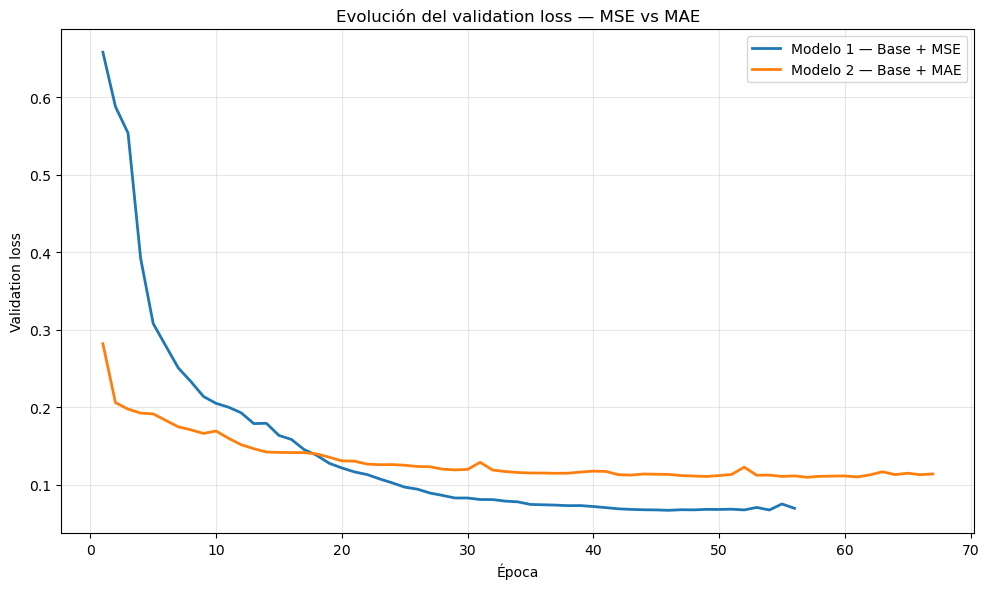

In [14]:
plot_training_metric_comparison(
    aggregated_df=loss_comparison_df,
    model_labels=LOSS_COMPARISON_MODELS,
    metric_col="val_loss",
    ylabel="Validation loss",
    title="Evolución del validation loss — MSE vs MAE",
)

Las curvas de entrenamiento y validación muestran un comportamiento muy similar para ambas funciones de pérdida, alcanzando una convergencia estable y sin evidencias de sobreajuste. Sin embargo, el modelo entrenado mediante MSE presenta una velocidad de convergencia superior y obtiene de forma consistente menores valores de pérdida tanto sobre el conjunto de entrenamiento como sobre el de validación.

Dado que ambas configuraciones únicamente difieren en la función de pérdida empleada durante el entrenamiento, los resultados obtenidos indican que el uso de MSE proporciona una mejor capacidad de reconstrucción del tráfico benigno global que MAE para la arquitectura considerada.

**Como consecuencia, en el resto de la experimentación se priorizarán configuraciones basadas en MSE**, descartando el uso de MAE salvo que su combinación con otras decisiones de diseño aporte alguna ventaja significativa.

## 2. Influencia de la capacidad de codificación del autoencoder

En esta segunda comparación se analiza el efecto de aumentar la capacidad de codificación del autoencoder global. Para ello se comparan 2 modelos entrenados con la misma función de pérdida y bajo las mismas condiciones experimentales, modificando únicamente la dimensión de las capas ocultas del encoder.

El objetivo es comprobar si una arquitectura con mayor capacidad permite modelar mejor la distribución conjunta del tráfico benigno de los nueve dispositivos IoT, o si la arquitectura base resulta suficiente para capturar los patrones normales presentes en el conjunto global.

In [15]:
CAPACITY_COMPARISON_MODELS = {
    "model_1_base_mse": "Modelo 1 — Base + MSE",
    "model_3_higher_capacity_mse": "Modelo 3 — Mayor capacidad + MSE",
}

capacity_comparison_df = histories_df[
    histories_df["model_id"].isin(CAPACITY_COMPARISON_MODELS.keys())
].copy()

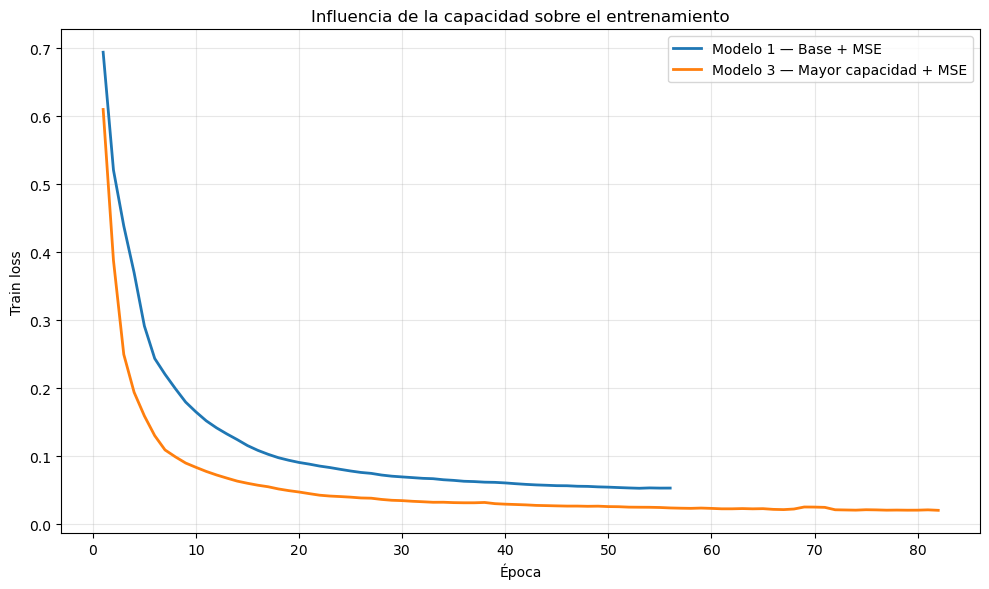

In [16]:
plot_training_metric_comparison(
    aggregated_df=capacity_comparison_df,
    model_labels=CAPACITY_COMPARISON_MODELS,
    metric_col="loss",
    ylabel="Train loss",
    title="Influencia de la capacidad sobre el entrenamiento",
)

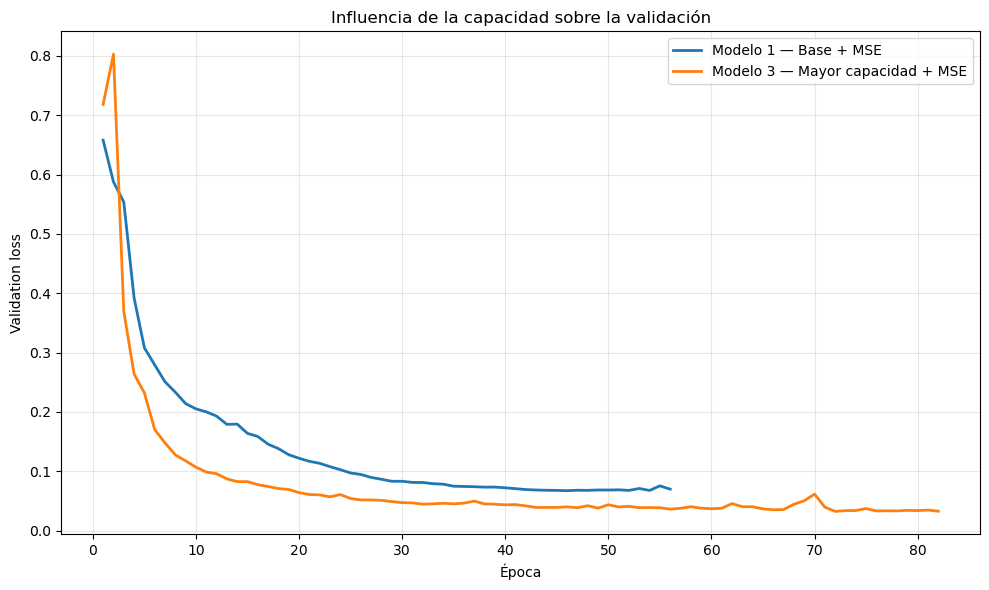

In [17]:
plot_training_metric_comparison(
    aggregated_df=capacity_comparison_df,
    model_labels=CAPACITY_COMPARISON_MODELS,
    metric_col="val_loss",
    ylabel="Validation loss",
    title="Influencia de la capacidad sobre la validación",
)

Las curvas muestran que el aumento de capacidad tiene un efecto positivo en el autoencoder global. El modelo de mayor capacidad converge más rápido, alcanza pérdidas de entrenamiento y validación inferiores, y continúa mejorando durante un mayor número de épocas.

Este resultado contrasta con lo observado en la experimentación del autoencoder específico por dispositivo, donde una arquitectura más compacta era suficiente. En este caso, la diferencia es coherente con la naturaleza del problema: el modelo global debe reconstruir tráfico benigno procedente de dispositivos heterogéneos, por lo que necesita una mayor capacidad de representación para capturar patrones normales más diversos.

Además, no se observan evidencias claras de sobreajuste, ya que la mejora en entrenamiento se acompaña también de una mejora sostenida en validación. Por tanto, **la arquitectura de mayor capacidad se considera más prometedora para el autoencoder global**.

## 3. Influencia de la regularización

La última comparación analiza el efecto de incorporar regularización sobre la arquitectura de mayor capacidad, que en el apartado anterior ha mostrado el comportamiento más prometedor para el autoencoder global.

Para ello se comparan dos modelos con la misma capacidad de codificación y la misma función de pérdida, diferenciándose únicamente por la incorporación de mecanismos de regularización en el segundo caso. Esta comparación permite comprobar si técnicas como L2, Dropout, Batch Normalization y LeakyReLU ayudan a mejorar la generalización del modelo global o si, por el contrario, dificultan el aprendizaje de una representación suficientemente precisa del tráfico benigno agregado.

In [18]:
REGULARIZATION_COMPARISON_MODELS = {
    "model_3_higher_capacity_mse": "Modelo 3 — Mayor capacidad + MSE",
    "model_5_higher_capacity_regularized_mse": "Modelo 5 — Mayor capacidad regularizado + MSE",
}

regularization_comparison_df = histories_df[
    histories_df["model_id"].isin(REGULARIZATION_COMPARISON_MODELS.keys())
].copy()

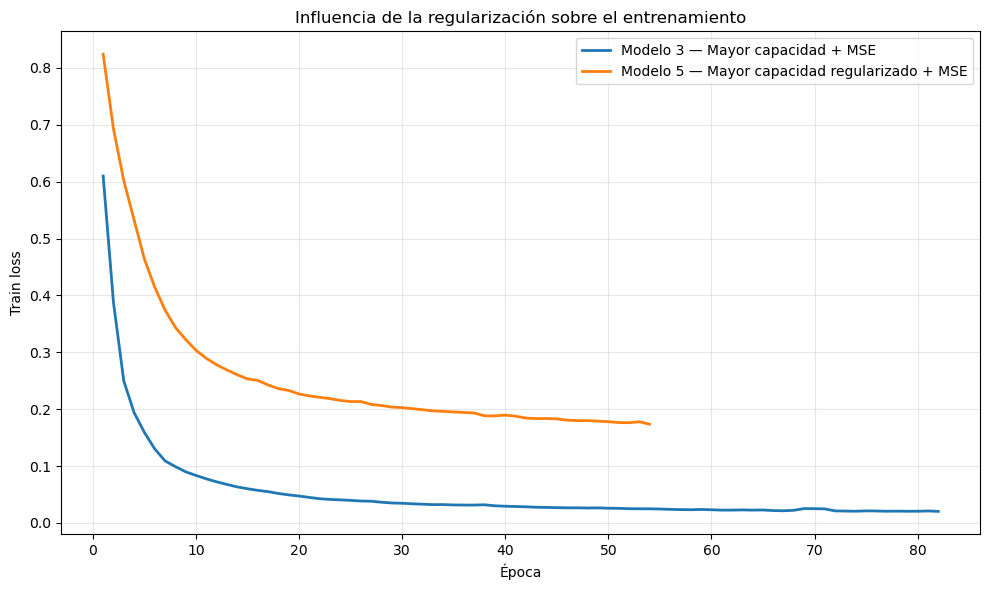

In [19]:
plot_training_metric_comparison(
    aggregated_df=regularization_comparison_df,
    model_labels=REGULARIZATION_COMPARISON_MODELS,
    metric_col="loss",
    ylabel="Train loss",
    title="Influencia de la regularización sobre el entrenamiento",
)

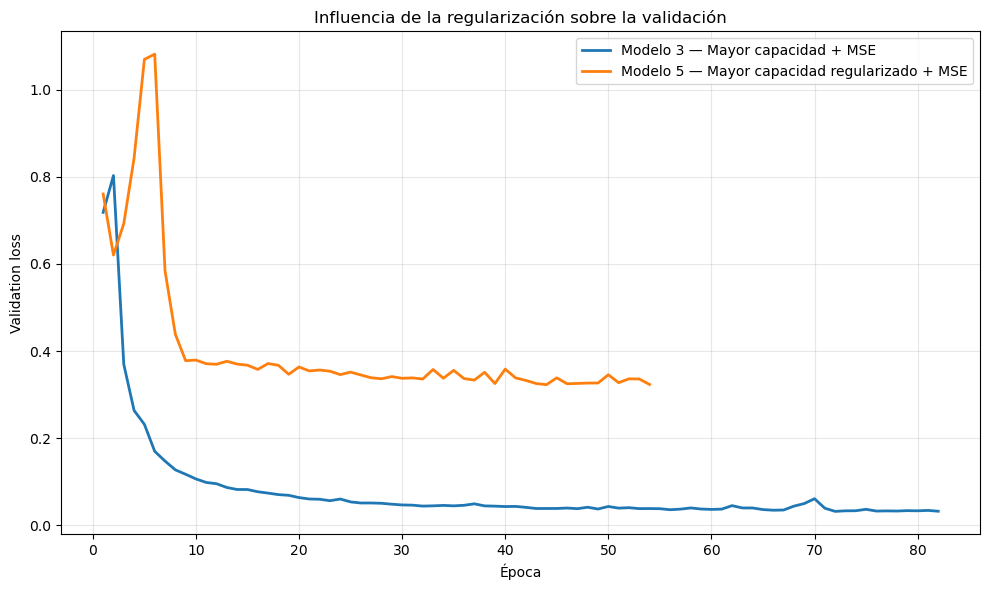

In [20]:
plot_training_metric_comparison(
    aggregated_df=regularization_comparison_df,
    model_labels=REGULARIZATION_COMPARISON_MODELS,
    metric_col="val_loss",
    ylabel="Validation loss",
    title="Influencia de la regularización sobre la validación",
)

Las curvas muestran que el modelo regularizado obtiene un comportamiento claramente inferior al modelo de mayor capacidad sin regularización. Tanto en entrenamiento como en validación, la pérdida se mantiene en valores considerablemente más altos, lo que indica que la configuración evaluada dificulta el aprendizaje de una representación precisa del tráfico benigno global.

No obstante, dado que en esta comparación se introducen simultáneamente varios cambios —regularización L2, Dropout, Batch Normalization y LeakyReLU—, no es posible atribuir el deterioro observado a un único componente de forma aislada. Lo que sí puede concluirse es que esta combinación concreta no resulta adecuada para el autoencoder global en las condiciones evaluadas.

En particular, se descarta el uso de **LeakyReLU** en los siguientes stages, ya que tampoco ha mostrado ventajas en la experimentación previa y añade una fuente adicional de variabilidad respecto a las arquitecturas basadas en ReLU. En cambio, otras técnicas de regularización podrán reconsiderarse de forma más controlada si fuera necesario durante la optimización posterior.

## 4. Decisiones para el stage 2 de la experimentación

A partir de los resultados obtenidos durante este primer *stage* se establecen varias decisiones que permiten reducir el espacio de búsqueda de la optimización de hiperparámetros y centrar el análisis en las configuraciones más prometedoras.

En primer lugar, **se fija MSE como función de pérdida**, ya que ha mostrado una convergencia más rápida y menores pérdidas tanto sobre el conjunto de entrenamiento como sobre el de validación que MAE.

En segundo lugar, **se adopta ReLU como función de activación en las capas ocultas**. La única configuración que incorporaba LeakyReLU, junto con otras técnicas de regularización, no ha mostrado ventajas frente a las arquitecturas basadas en ReLU, por lo que se opta por mantener una arquitectura más sencilla.

Además, **se tomará como referencia la arquitectura de mayor capacidad**, ya que ha obtenido menores pérdidas de entrenamiento y validación que la arquitectura base. Por tanto, el espacio de búsqueda del Stage 2 se definirá alrededor de esta configuración, permitiendo ajustar sus dimensiones pero evitando volver a arquitecturas claramente menos expresivas. Las dimensiones de esta arquitectura de mayor capacidad serían las siguientes:

```text
115 → 86 → 57 → 38 → 12 → 38 → 57 → 86 → 115

Lo único que variará de esta arquitectura será la dimensión latente en la optimización de hiperparámetros

Asimismo, se incorporará el callback **ReduceLROnPlateau** durante el entrenamiento para favorecer la convergencia de las arquitecturas de mayor capacidad cuando la mejora sobre el conjunto de validación se ralentice.

Finalmente, aunque la optimización de hiperparámetros se realizará utilizando un máximo de **100 épocas** para mantener un coste computacional razonable, el modelo definitivo obtenido tras el proceso de optimización se reentrenará durante un máximo de **200 épocas**, empleando *Early Stopping* para detener automáticamente el entrenamiento cuando el rendimiento sobre el conjunto de validación deje de mejorar. De este modo, el modelo final podrá aprovechar completamente su capacidad de aprendizaje sin incrementar innecesariamente el coste de la búsqueda de hiperparámetros.